----------------------------------Student Performance Indicator--------------------------------

problem statements is

the projects understands how the student's  performance affected by variables such as gender,ethincity,parent level of education,study preparation course and lunch

life cycle of this project is 

1.Understand the problem statement.

2.Data collection

3.Data check to perform

4.Exploratory Data Analysis

5.Data pre-processing

6.Model training

7.Choose best model

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')



In [150]:
pd.set_option("display.max_columns",None)
# pd.set_option("display.max_rows",None)
pd.set_option("display.max_colwidth",None)



In [ ]:
df=pd.read_csv("stud.csv")
print(df.head)

<bound method NDFrame.head of      gender race_ethnicity parental_level_of_education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
5    female        group B          associate's degree      standard   
6    female        group B                some college      standard   
7      male        group B                some college  free/reduced   
8      male        group D                 high school  free/reduced   
9    female        group B                 high school  free/reduced   
10     male        group C          associate's degree      standard   
11     male        group D          associate's degree      standard   
12   female        group B        

: 

In [56]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [57]:
df.isnull().sum()
duplicate=df.loc[df.duplicated]
print(duplicate)

Empty DataFrame
Columns: [gender, race_ethnicity, parental_level_of_education, lunch, test_preparation_course, math_score, reading_score, writing_score]
Index: []


In [58]:
duplicates=df.duplicated().sum()
duplicate=df.loc[df.duplicated]
print(duplicate)
df=df.drop_duplicates()
print(df.duplicated().sum())

Empty DataFrame
Columns: [gender, race_ethnicity, parental_level_of_education, lunch, test_preparation_course, math_score, reading_score, writing_score]
Index: []
0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


checking the number of unique values of each column

In [60]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [61]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


EDA

In [81]:
print("categories in 'gender' variable",end=" ")
print(df['gender'].unique())
print(df.columns)

categories in 'gender' variable ['female' 'male']
Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average'],
      dtype='object')


In [82]:
print("categories in 'race_ethnicity' variable",end=" ")
print(df['race_ethnicity'].unique())

print("categories in 'gender' variable",end=" ")
print(df['gender'].unique())

print("categories in 'parental_level_of_education' variable",end=" ")
print(df['parental_level_of_education'].unique())

print("categories in 'lunch' variable",end=" ")
print(df['lunch'].unique())

print("categories in 'test_preparation_course' variable",end=" ")
print(df['test_preparation_course'].unique())


categories in 'race_ethnicity' variable ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'gender' variable ['female' 'male']
categories in 'parental_level_of_education' variable ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable ['standard' 'free/reduced']
categories in 'test_preparation_course' variable ['none' 'completed']


In [64]:
numerical_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_feature=[feature for feature in df.columns if df[feature].dtype=='O']

print("there are total {} numerical feature are there those are {}".format(len(numerical_features),numerical_features))
print("\nthere are total {} categorical features are there those are {}".format(len(categorical_feature),categorical_feature))

there are total 3 numerical feature are there those are ['math_score', 'reading_score', 'writing_score']

there are total 5 categorical features are there those are ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [66]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total_score']/3
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667


In [67]:
math_full=df[df['math_score']==100]['average'].count()
reading_full=df[df['reading_score']==100]['average'].count()
writing_full=df[df['writing_score']==100]['average'].count()

print(f"there are total {math_full} number of students are scored 100 on math ")
print(f"there are total {reading_full} number of students are scored 100 on reading ")
print(f"there are total {writing_full} number of students are scored 100 on writing ")

there are total 7 number of students are scored 100 on math 
there are total 17 number of students are scored 100 on reading 
there are total 14 number of students are scored 100 on writing 


In [68]:
math_less=df[df['math_score']<=20]['average'].count()
read_less=df[df['reading_score']<=20]['average'].count()
write_less=df[df['writing_score']<=20]['average'].count()

print(f"there are total {math_less} numbers of students are weak in math")
print(f"there are total {read_less} numbers of students are weak in reading")
print(f"there are total {write_less} numbers of students are weak in writing")



there are total 4 numbers of students are weak in math
there are total 1 numbers of students are weak in reading
there are total 3 numbers of students are weak in writing


from the above lines we get to know that most students are performed worst in math
best performance in reading


DATA VISUALIZATION

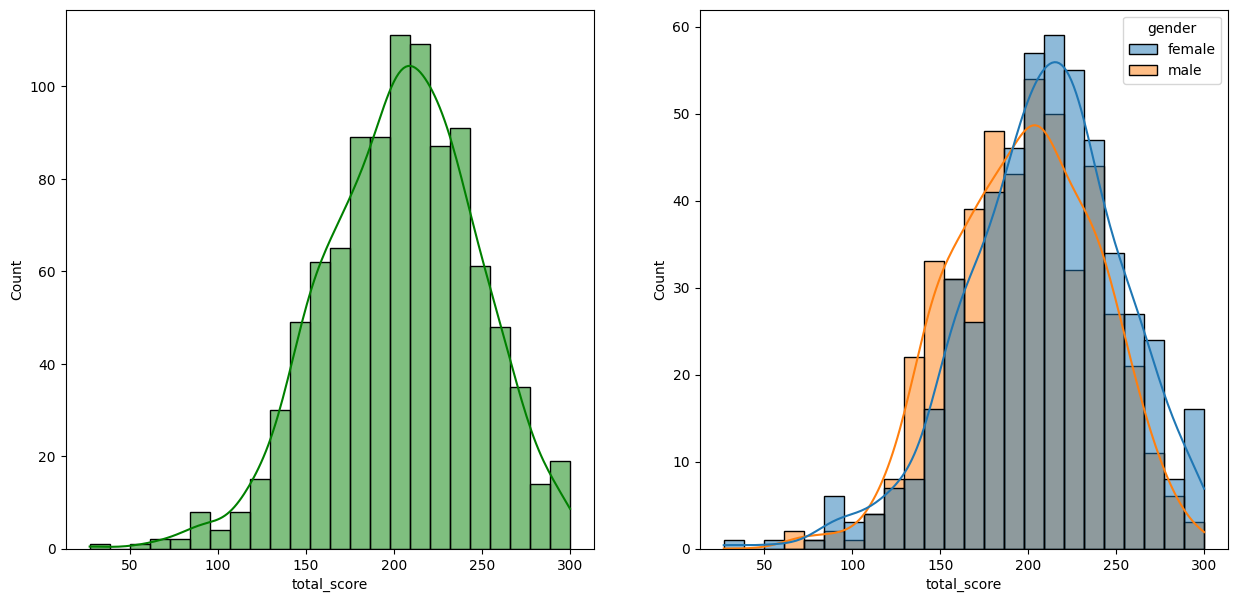

In [69]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

In [87]:
print(df['lunch'].value_counts())

lunch
standard        645
free/reduced    355
Name: count, dtype: int64


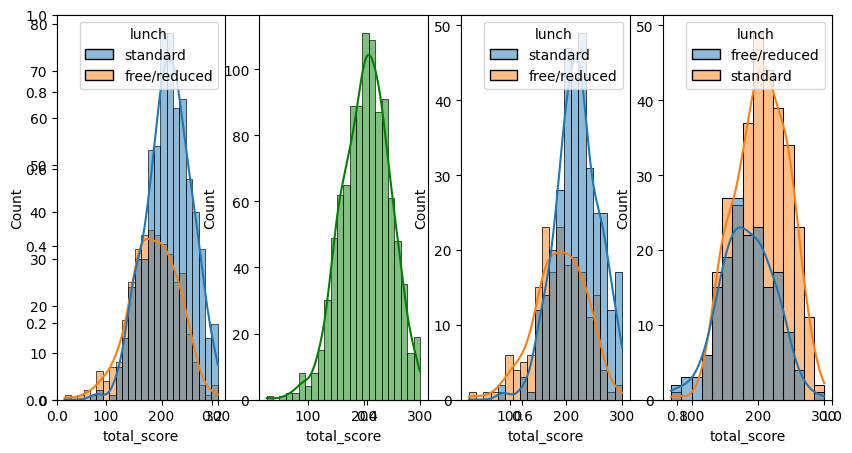

In [101]:
plt.subplots(1,1,figsize=(10,5))
plt.subplot(141)
sns.histplot(data=df,x='total_score',kde=True,color='g',hue='lunch')
plt.subplot(142)
sns.histplot(data=df,x='total_score',kde=True,color='g')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='total_score',kde=True,hue='lunch')
plt.subplot(144)
sns.histplot(data=df[df.gender=='male'],x='total_score',kde=True,hue='lunch')
plt.show()

standard lunce helped in perform well in exams


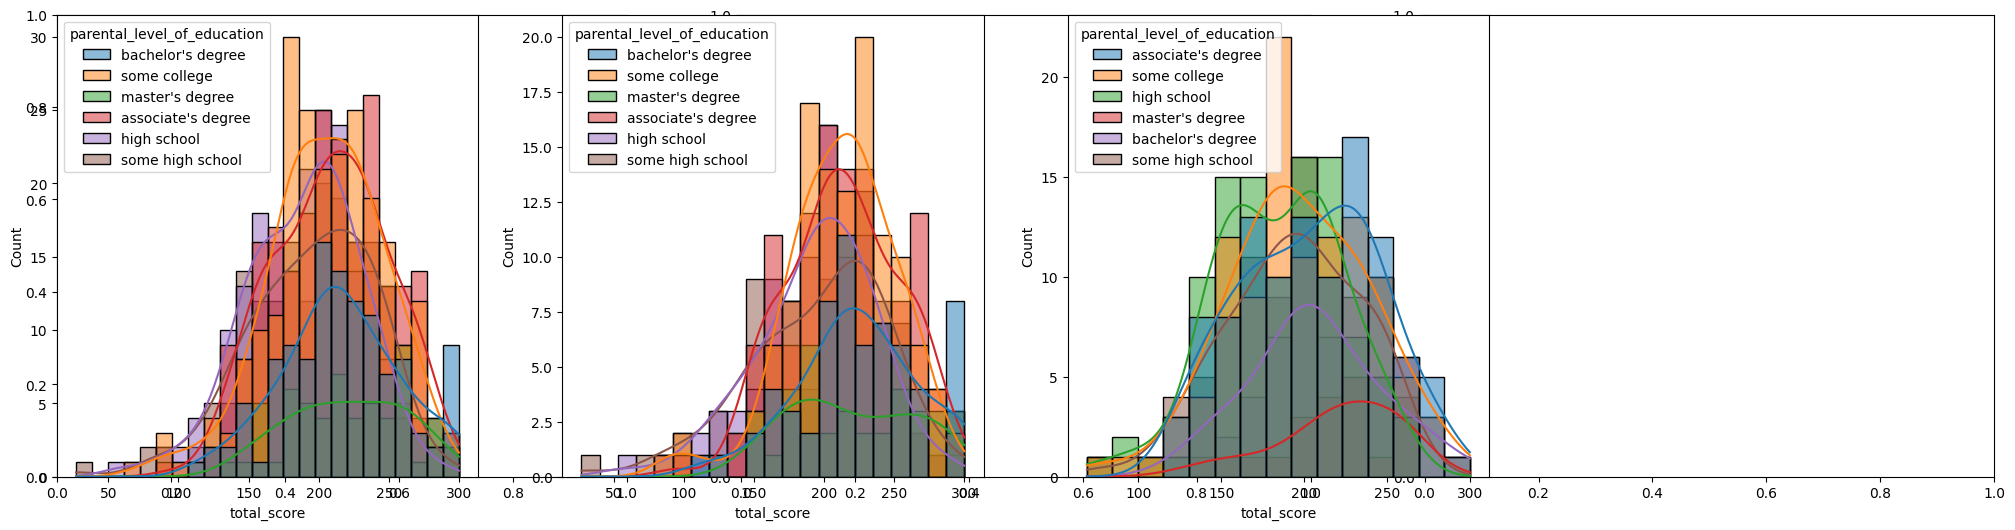

In [71]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='total_score',kde=True,hue='parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='total_score',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='total_score',kde=True,hue='parental_level_of_education')
plt.show()

in general parent  level of education that does not helps in student perform well in exam
in 2nd plot there is no effect of parents education on female students examination
3rd plots shows the parents with their associate's degree that made effect on there male students exams


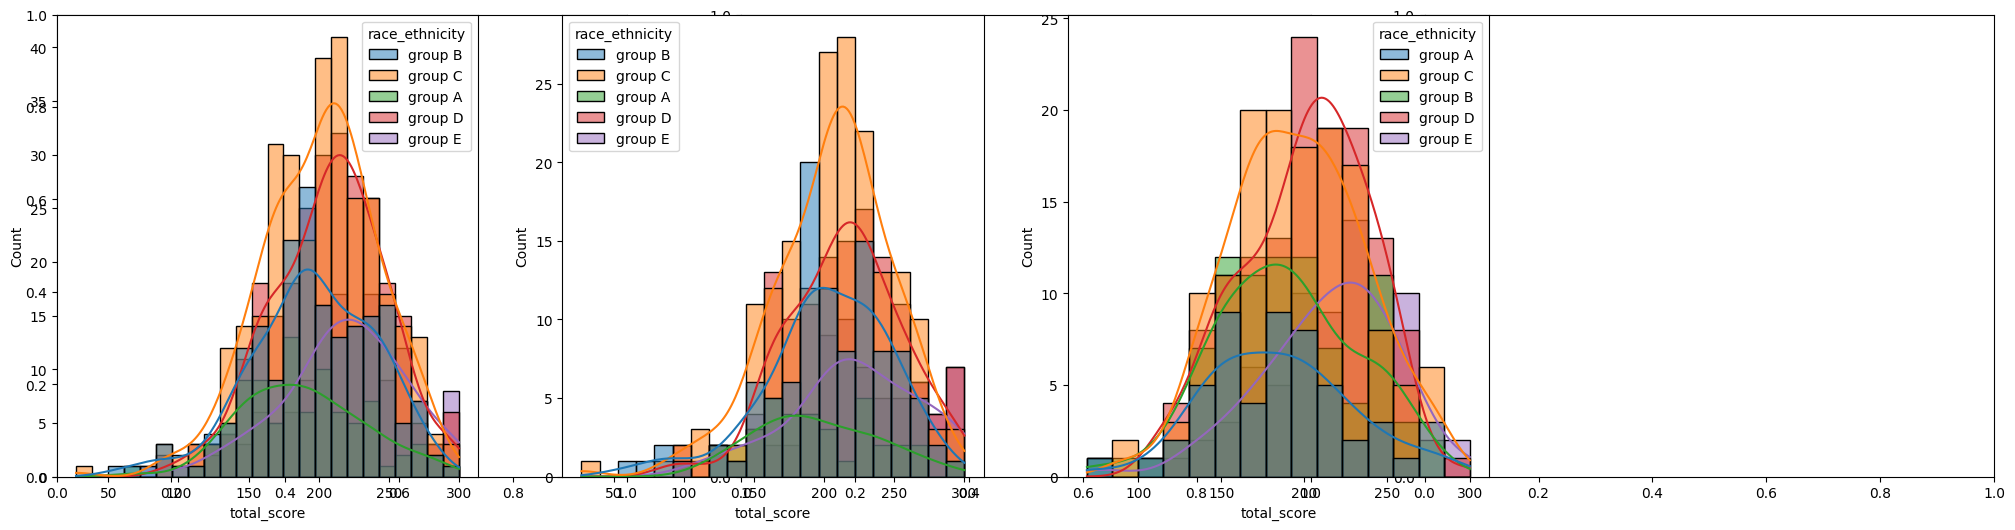

In [73]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='total_score',kde=True,hue='race_ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='total_score',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='total_score',kde=True,hue='race_ethnicity')
plt.show()

maximum scores of students in all three subjects

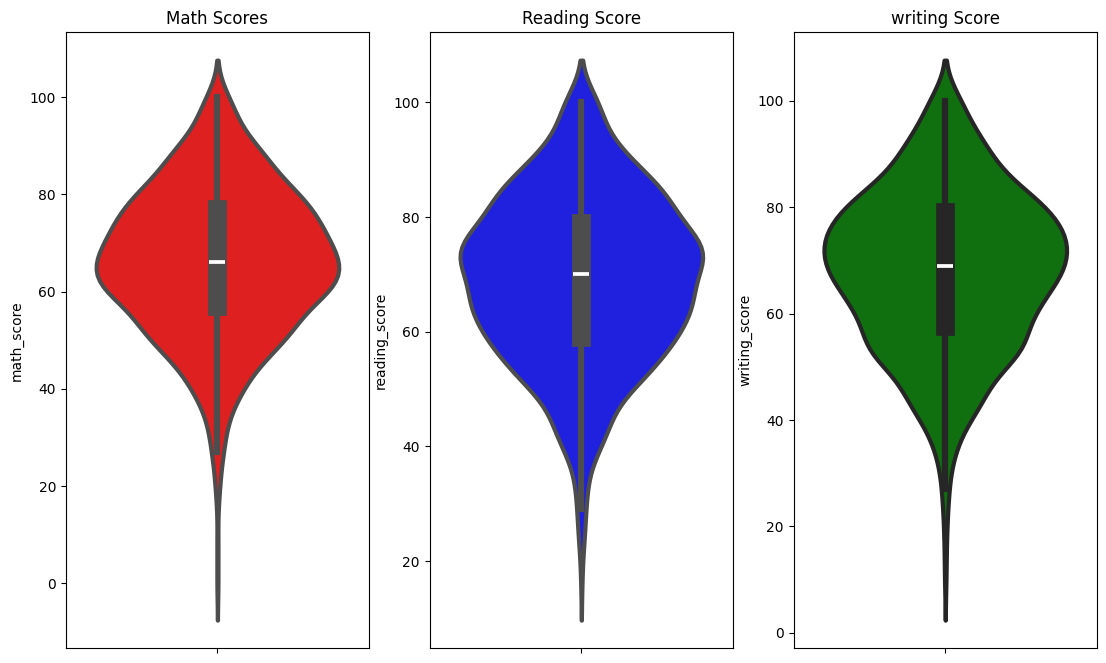

In [105]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Scores')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title("Reading Score")
sns.violinplot(data=df,y='reading_score',color='blue',linewidth=3)
plt.subplot(1,4,3)
plt.title("writing Score")
sns.violinplot(data=df,y='writing_score',color='green',linewidth=3)
plt.show()


from the above 3 plots it's clearly visible that most of the students score in between 60-80 in maths where as reading and writing the most of them score from 50-80

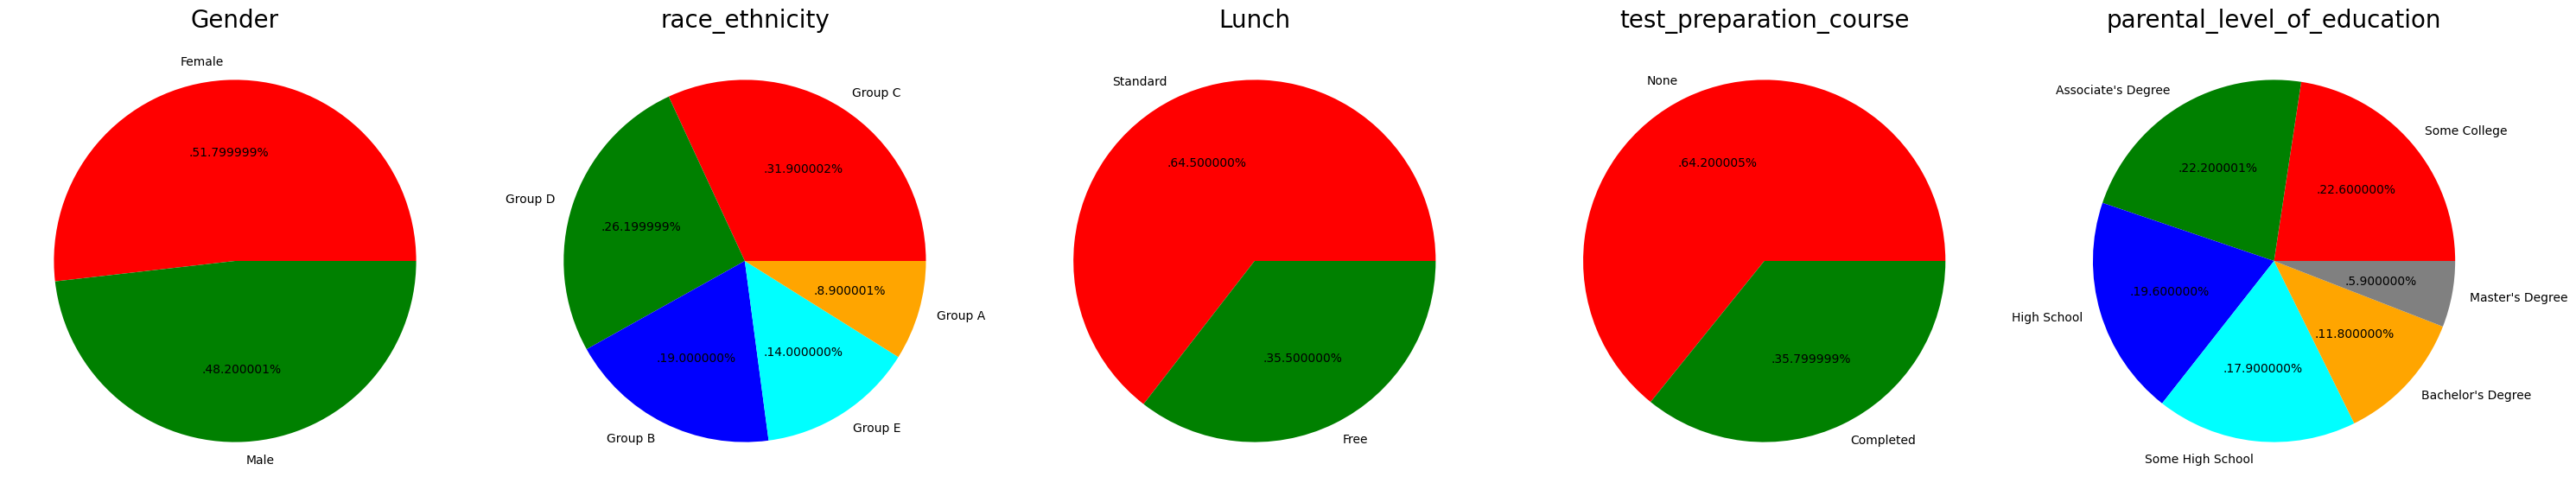

In [108]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('race_ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('test_preparation_course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('parental_level_of_education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

Insights:
number of male and female students are almost equal
number of students are greatest in group c
number of students who have standard lunch are greater
most number of students are not enrolled in test preparation course 
number of students whose parental education is "some college" is greater followed by "associate degree"



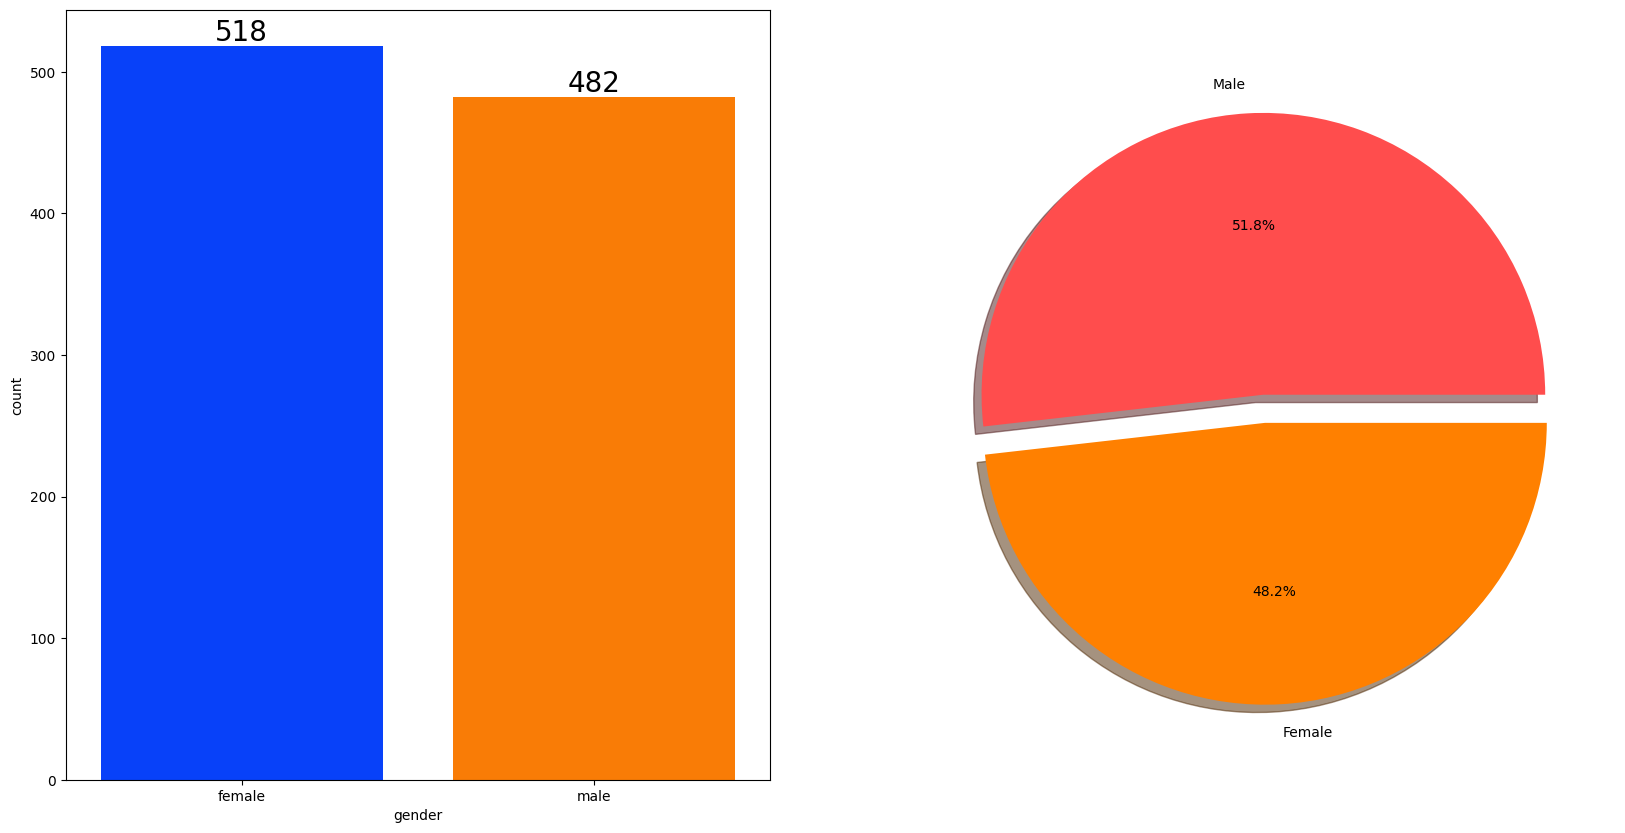

In [109]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

insights:
Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

In [115]:
df.dtypes

gender                          object
race_ethnicity                  object
parental_level_of_education     object
lunch                           object
test_preparation_course         object
math_score                       int64
reading_score                    int64
writing_score                    int64
total_score                      int64
average                        float64
dtype: object

BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [116]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


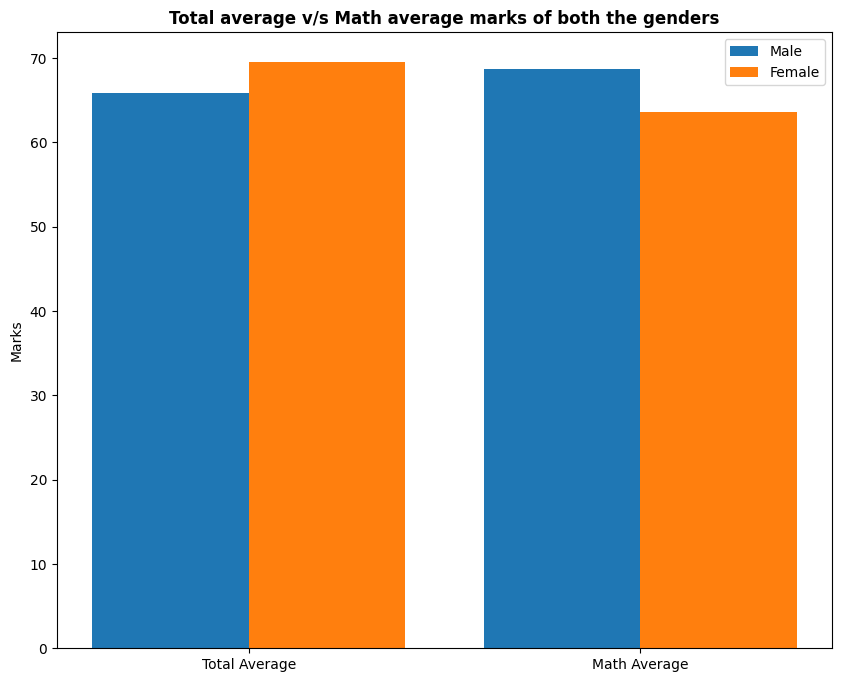

In [122]:


plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']

female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

Insights
On an average females have a better overall score than men.
whereas males have scored higher in Maths.

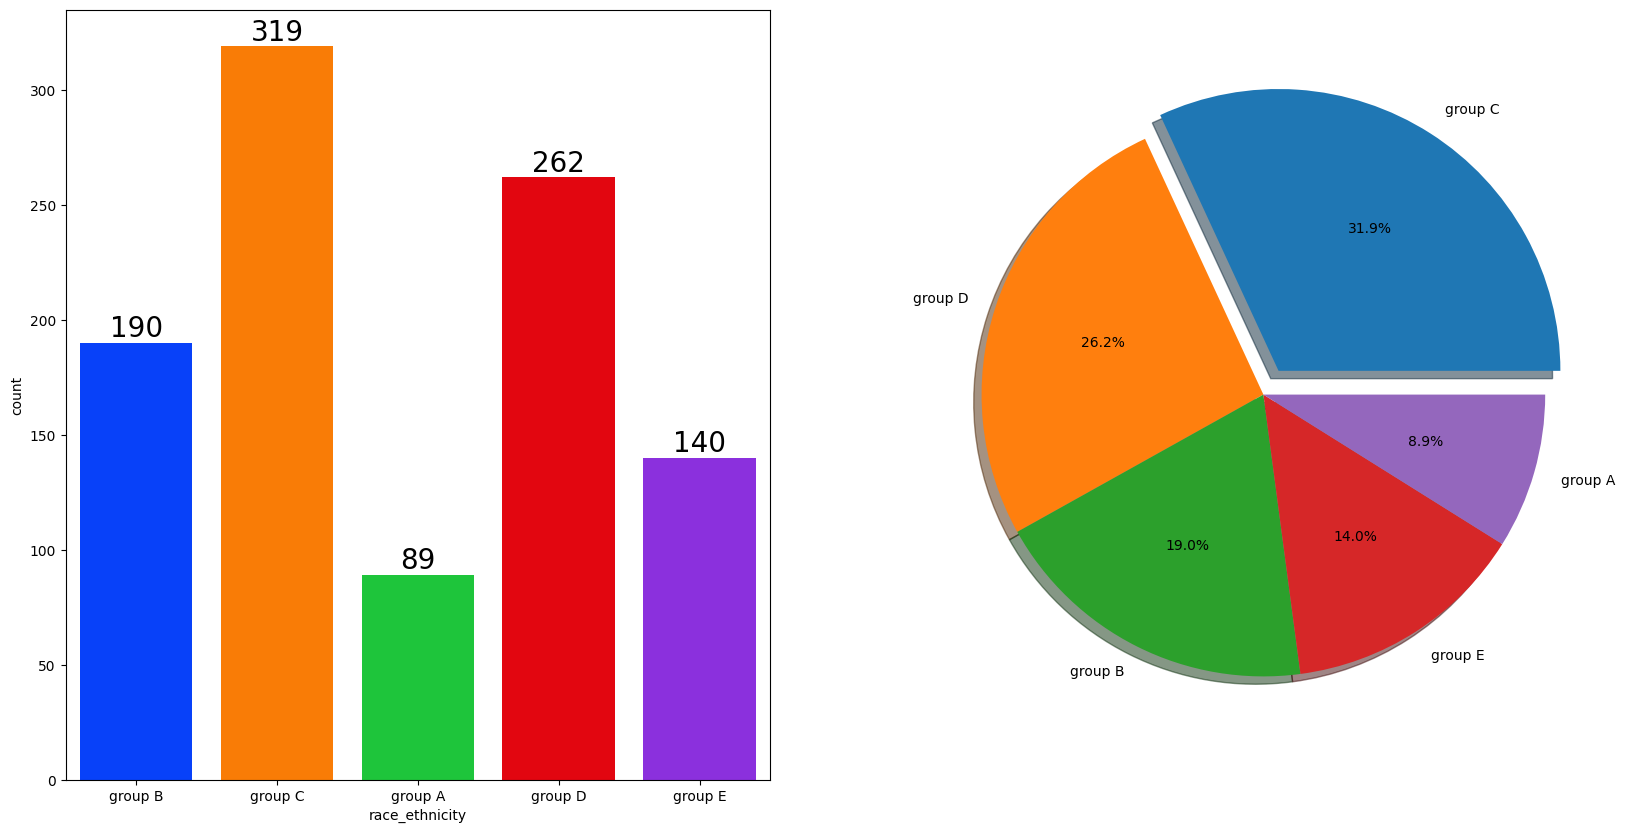

In [124]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show() 

Insights
Most of the student belonging from group C /group D.
Lowest number of students belong to groupA.

BIVARIATE ANALYSIS ( Is Race_Ehnicity has any impact on student's performance ? )

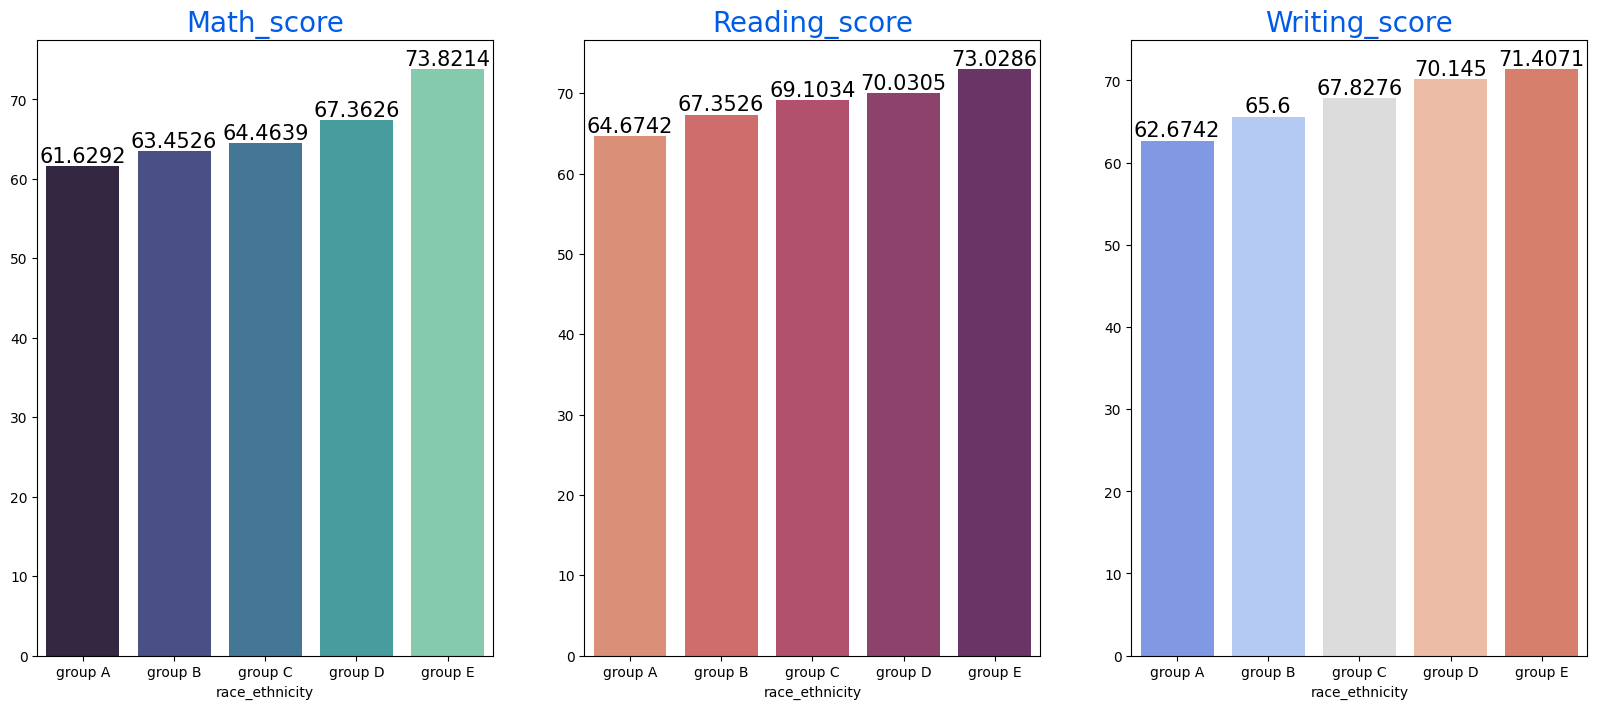

In [126]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math_score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading_score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing_score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

Insights

Group E students have scored the highest marks.

Group A students have scored the lowest marks.

Students from a lower Socioeconomic status have a lower avg in all course subjects

what is the educational background of student's parents 


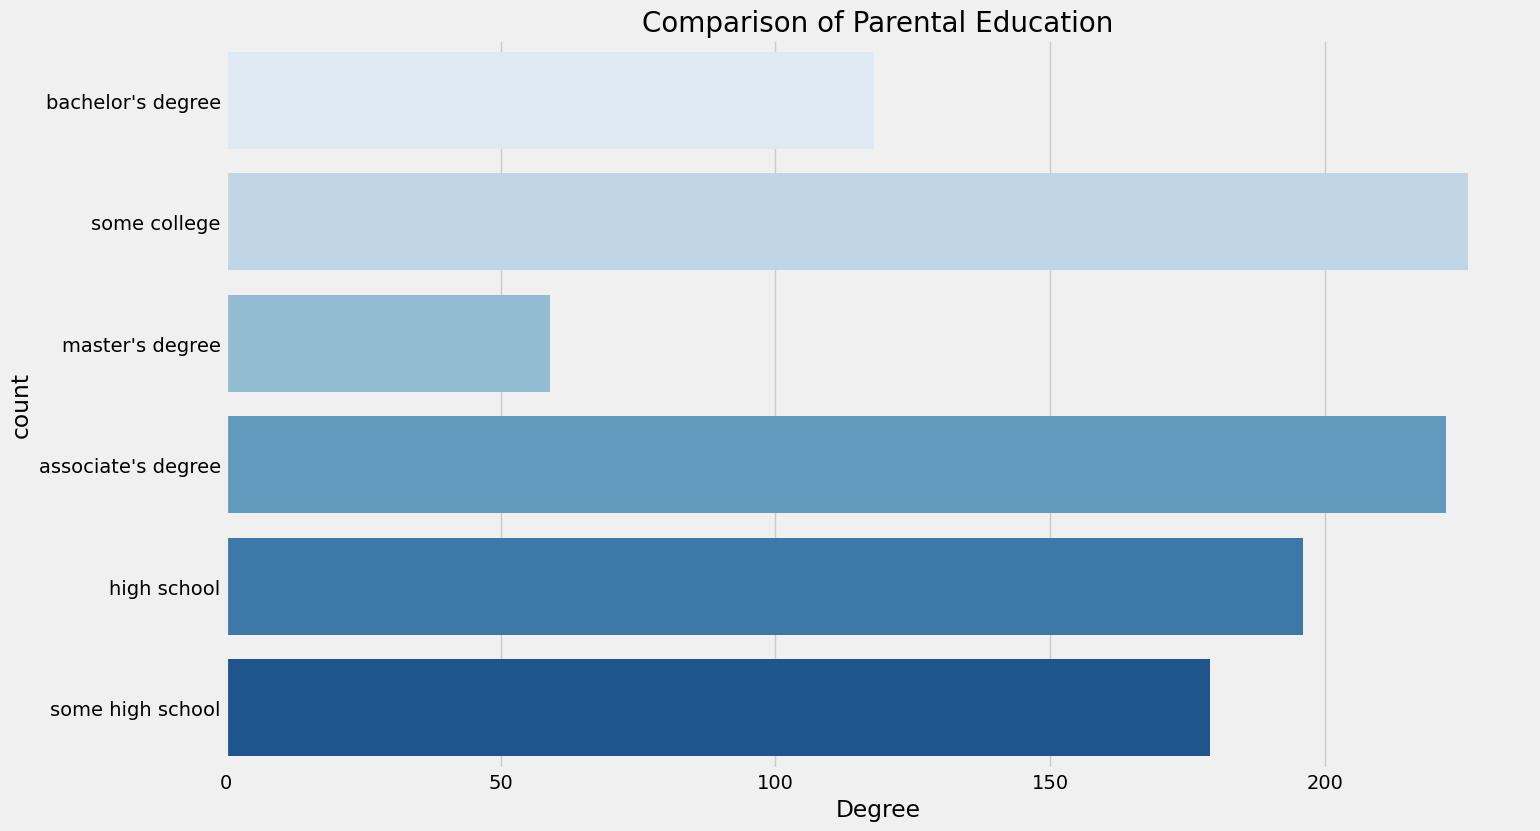

In [130]:
print("what is the educational background of student's parents ")
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

Insights:

Largest number of parents are from some college.

BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

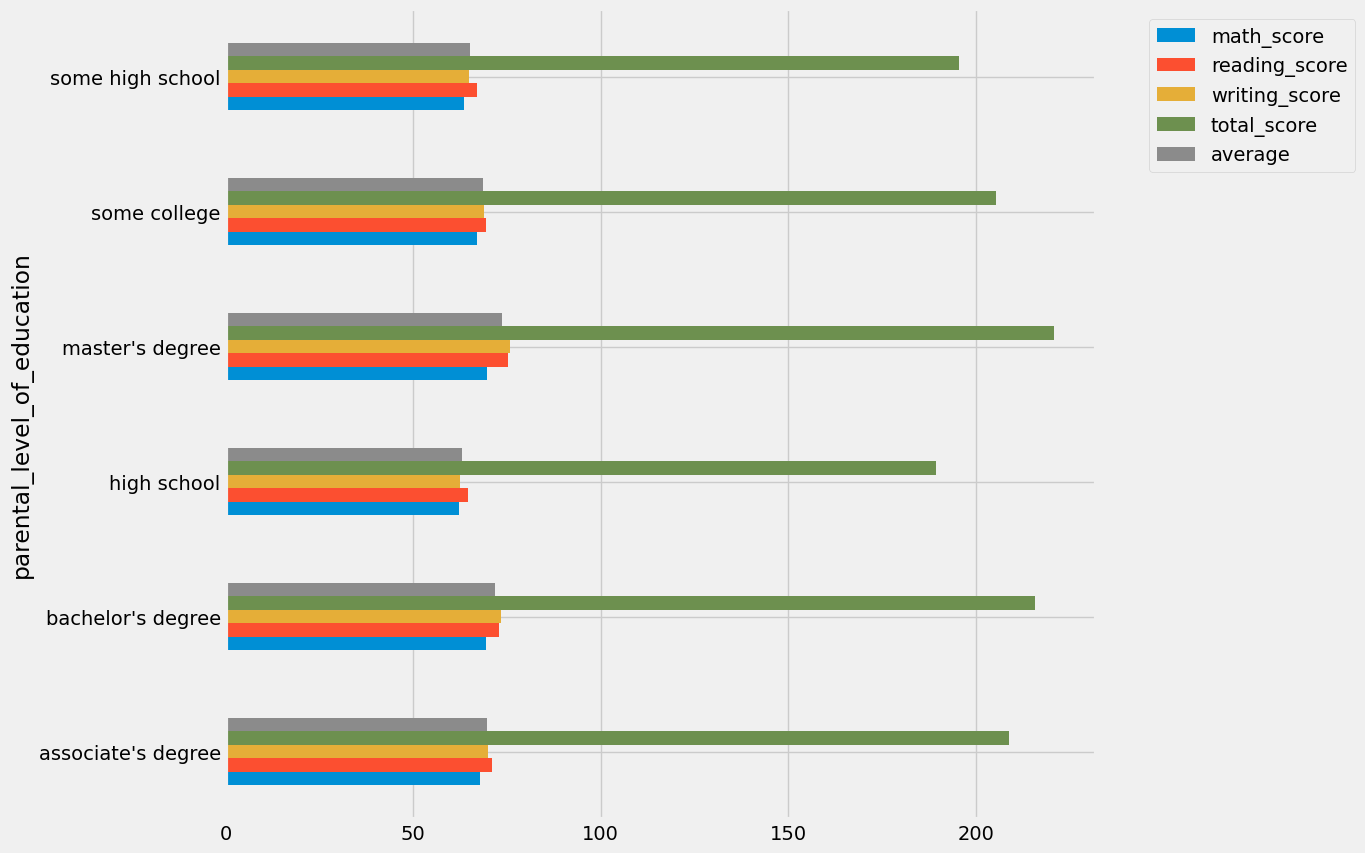

In [134]:
df.groupby("parental_level_of_education").mean(numeric_only=True).plot(
    kind="barh",
    figsize=(10,10)
)

plt.legend(bbox_to_anchor=(1.05,1), loc=2)
plt.show()

insights:
The score of student whose parents possess master and bachelor level education are higher than others.

Which type of lunch is most common amoung students ? 

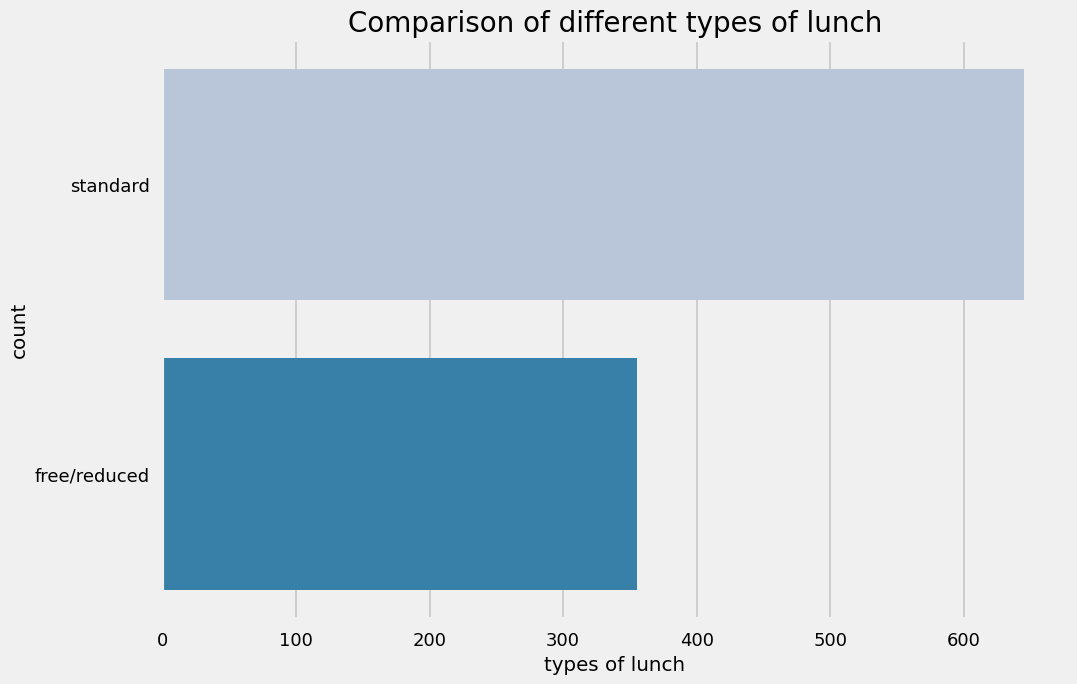

In [139]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

Insights:
Students being served Standard lunch was more than free lunch

---Is lunch type intake has any impact on student's performance ?---

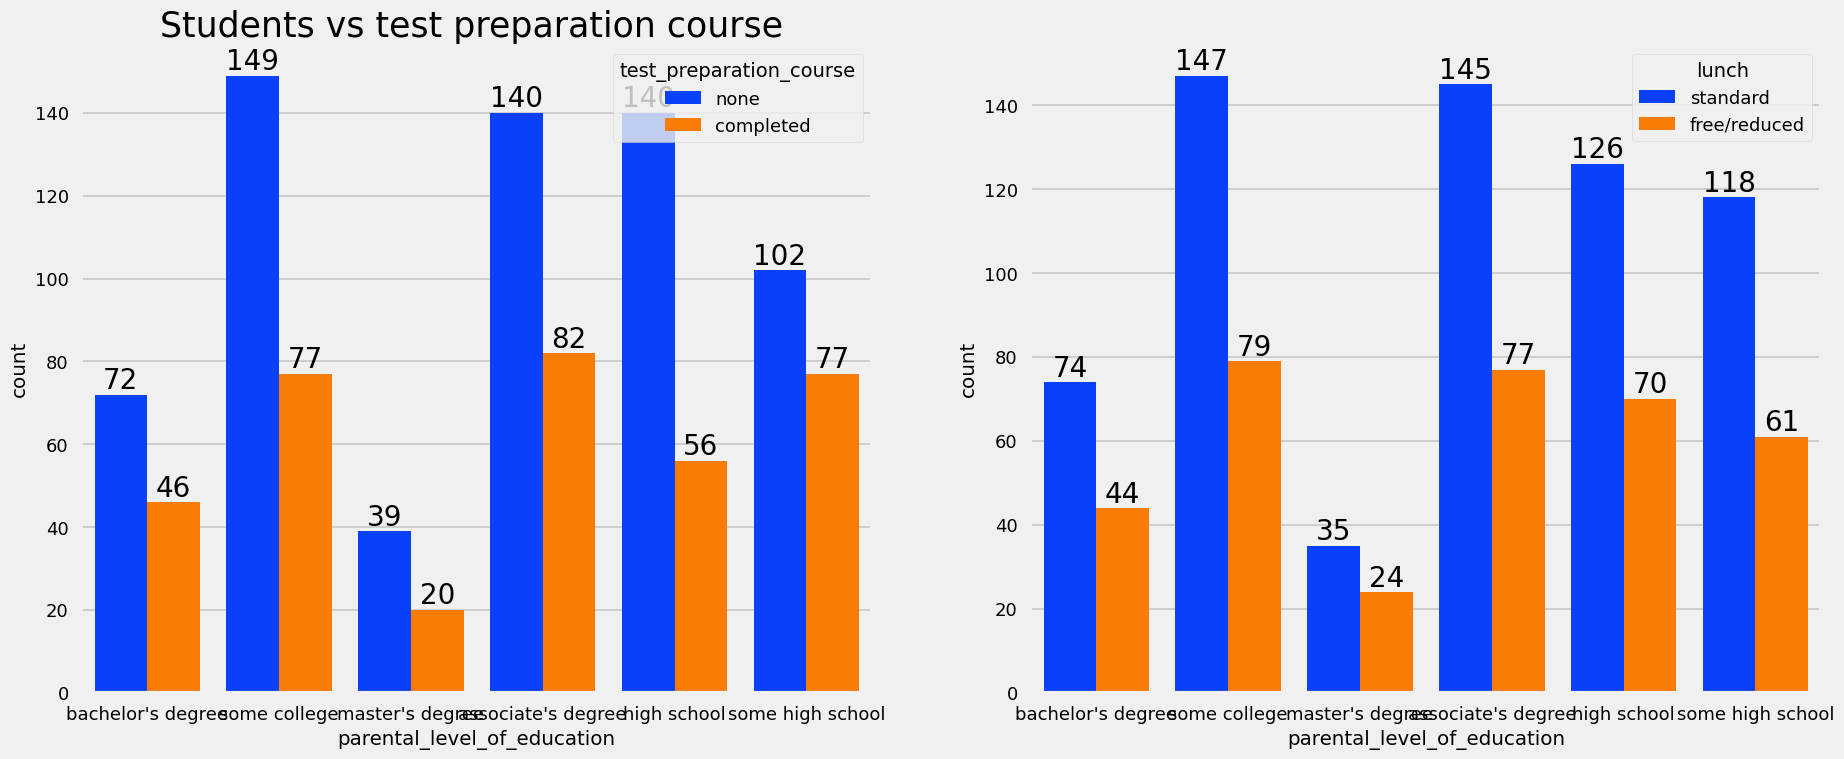

In [141]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

print("does the test preparation course has any impact on students exam performance?")

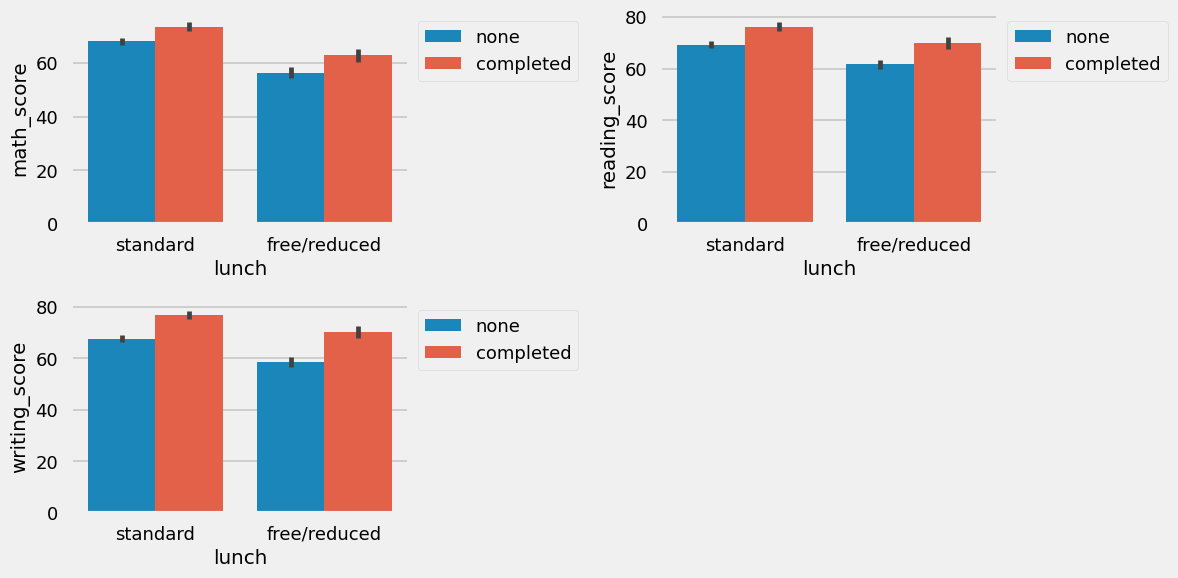

In [144]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
ax1 = sns.barplot(x='lunch',
                  y='math_score',
                  hue='test_preparation_course',
                  data=df)
ax1.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.subplot(2,2,2)
ax2 = sns.barplot(x='lunch',
                  y='reading_score',
                  hue='test_preparation_course',
                  data=df)
ax2.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.subplot(2,2,3)
ax3 = sns.barplot(x='lunch',
                  y='writing_score',
                  hue='test_preparation_course',
                  data=df)
ax3.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

Insights
Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course
here I wanted to compare average student scores across different lunch categories while simultaneously separating students based on whether they completed the test preparation course. The hue parameter lets me compare both groups within each lunch category, making it easy to see whether the preparation course improves performance regardless of lunch type

checking the outliers

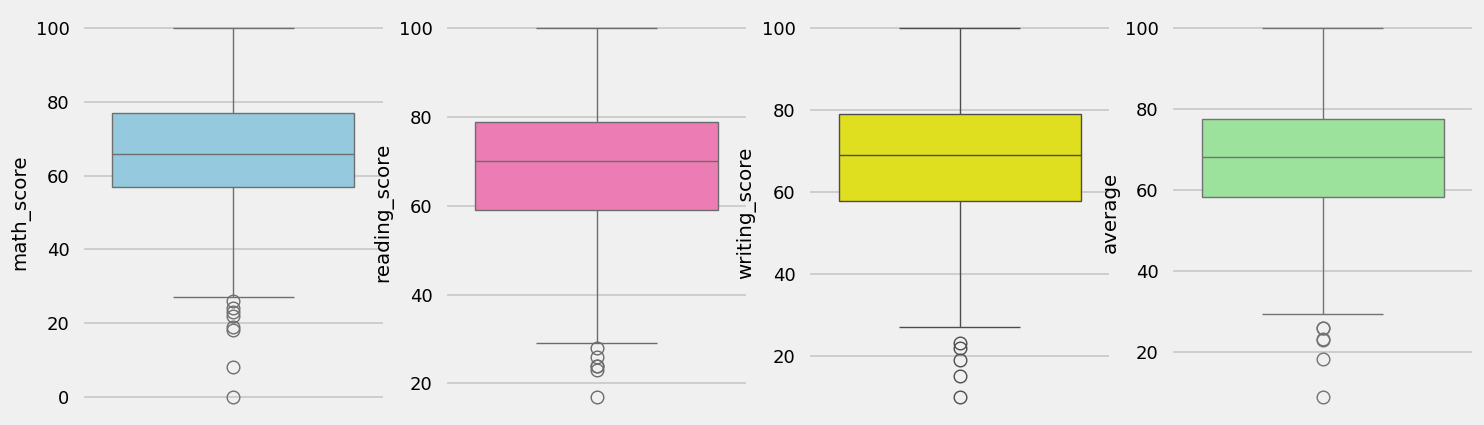

In [145]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

The writing and reading score boxes are slightly higher than the math score box.
The median lies around the mid-to-high 60s, indicating that the typical student scored around that range.
This tells us that, on average, students performed a little better in reading and writing than in math.
Overall, the dataset does not contain many extreme values."

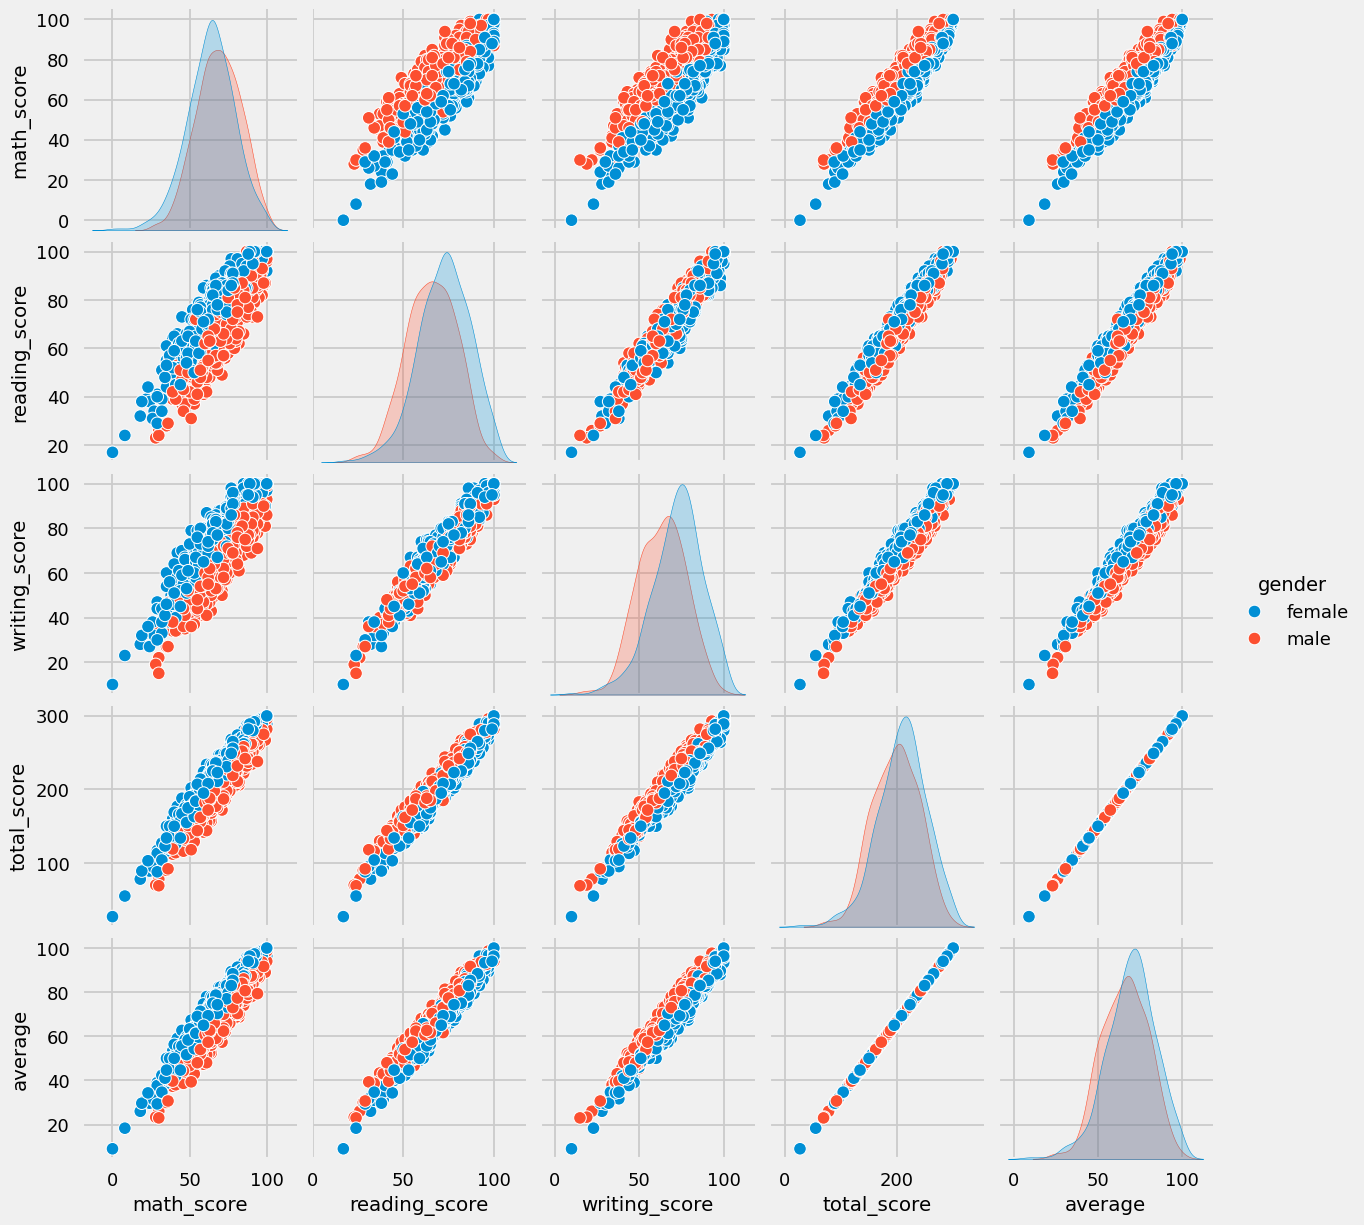

In [ ]:
sns.pairplot(df,hue = 'gender')
plt.show()


Insights:

The scatter plots show a strong positive correlation between math, reading, and writing scores. Students performing well in one subject generally perform well in the others

Females generally have slightly higher reading and writing scores

Total score and average have a perfect linear relationship because average is derived from total score because average is calculated from total score.
There is no large difference in math performance between males and females.

Most students scored around the middle.
Very few students scored extremely low or extremely high.

The dataset has very few outliers, and no separate clusters are visible.